# 09 — Optimized Strategy: Trend + S/R Zone + Momentum

**Konsep:**
- H1 → Trend utama (EMA 50) + S/R Zone dari 500 candle
- M15 → Entry timing: MACD histogram naik/turun + candle close konfirmasi
- Signal muncul = ketiga komponen sejajar → power signal
- Tidak tunggu RSI ekstrem, tidak butuh 4 indikator sekaligus

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

CSV = '../../app/ai/candle_ai/EURUSD.m_M15_202112160545_202603251830.csv'
df_raw = pd.read_csv(CSV, sep='\t')
df_raw.columns = [c.strip('<>').lower() for c in df_raw.columns]
df_raw['datetime'] = pd.to_datetime(df_raw['date'] + ' ' + df_raw['time'])
df_raw = df_raw.set_index('datetime').sort_index()
df_raw = df_raw[['open','high','low','close','tickvol']].rename(columns={'tickvol':'vol'})

print(f'M15: {len(df_raw):,} candles | {df_raw.index[0]} -> {df_raw.index[-1]}')

M15: 100,267 candles | 2021-12-16 05:45:00 -> 2026-03-25 18:30:00


In [2]:
# ── Indikator ──────────────────────────────────────────────────────────────
def ema(s, p): return s.ewm(span=p, adjust=False).mean()

def atr(df, p=14):
    h,l,c = df['high'], df['low'], df['close']
    tr = pd.concat([h-l, (h-c.shift()).abs(), (l-c.shift()).abs()], axis=1).max(axis=1)
    return tr.ewm(span=p, adjust=False).mean()

def macd_hist(s, fast=12, slow=26, sig=9):
    ml = s.ewm(span=fast,adjust=False).mean() - s.ewm(span=slow,adjust=False).mean()
    return ml - ml.ewm(span=sig,adjust=False).mean()

# ── H1 data ────────────────────────────────────────────────────────────────
df_h1 = df_raw.resample('1h').agg({'open':'first','high':'max','low':'min','close':'last'}).dropna()
df_h1['ema50']   = ema(df_h1['close'], 50)
df_h1['ema200']  = ema(df_h1['close'], 200)
df_h1['atr_h1']  = atr(df_h1, 14)
# Trend H1: EMA50 slope + posisi harga vs EMA200
df_h1['ema50_slope'] = df_h1['ema50'].diff(3)  # slope 3 candle
df_h1['trend'] = 'sideways'
df_h1.loc[(df_h1['ema50_slope'] > 0) & (df_h1['close'] > df_h1['ema200']), 'trend'] = 'up'
df_h1.loc[(df_h1['ema50_slope'] < 0) & (df_h1['close'] < df_h1['ema200']), 'trend'] = 'down'

# ── M15 data ───────────────────────────────────────────────────────────────
df = df_raw.copy()
df['atr']      = atr(df, 14)
df['macd_h']   = macd_hist(df['close'])           # MACD histogram
df['ema9']     = ema(df['close'], 9)
df['ema21']    = ema(df['close'], 21)

# Reindex H1 -> M15
df['trend_h1']  = df_h1['trend'].reindex(df.index, method='ffill')
df['ema50_h1']  = df_h1['ema50'].reindex(df.index, method='ffill')
df['ema200_h1'] = df_h1['ema200'].reindex(df.index, method='ffill')
df['atr_h1']    = df_h1['atr_h1'].reindex(df.index, method='ffill')

print(f'H1 trends: {df_h1["trend"].value_counts().to_dict()}')
print(f'M15 ready: {len(df):,} candles')

H1 trends: {'down': 10526, 'up': 10351, 'sideways': 5686}
M15 ready: 100,267 candles


In [3]:
# ── S/R Zone dari H1 (500 candle lookback) ─────────────────────────────────
# Swing high/low H1 → cluster jika dalam 10 pip → zona S/R kuat

H1_LOOKBACK  = 500
SW_WINDOW    = 4       # candle kiri-kanan untuk konfirmasi swing
CLUSTER_DIST = 0.0010  # 10 pip — level dianggap satu zona
PROX_ATR     = 1.2     # harga dianggap 'di zona' jika dalam 1.2x ATR H1

h1_high  = df_h1['high'].values
h1_low   = df_h1['low'].values
h1_close = df_h1['close'].values
h1_atr   = df_h1['atr_h1'].values
h1_idx   = df_h1.index
nh1      = len(df_h1)

# Pre-compute swing H1
is_sh = np.zeros(nh1, dtype=bool)
is_sl = np.zeros(nh1, dtype=bool)
for i in range(SW_WINDOW, nh1 - SW_WINDOW):
    if h1_high[i] == max(h1_high[i-SW_WINDOW:i+SW_WINDOW+1]):
        is_sh[i] = True
    if h1_low[i] == min(h1_low[i-SW_WINDOW:i+SW_WINDOW+1]):
        is_sl[i] = True

def get_sr_zones(swing_prices):
    """Cluster swing levels yang berdekatan → zona S/R."""
    if len(swing_prices) == 0:
        return []
    sorted_p = sorted(swing_prices)
    zones, cluster = [], [sorted_p[0]]
    for p in sorted_p[1:]:
        if p - cluster[-1] <= CLUSTER_DIST:
            cluster.append(p)
        else:
            zones.append(np.mean(cluster))
            cluster = [p]
    zones.append(np.mean(cluster))
    return zones

# Mapping M15 index ke H1 index
h1_idx_arr = np.array(h1_idx)
m15_idx    = df.index
nm15       = len(df)

# Untuk setiap M15 candle, cek apakah di zona S/R H1
m15_close  = df['close'].values
m15_atr_h1 = df['atr_h1'].values

in_support_zone    = np.zeros(nm15, dtype=bool)
in_resistance_zone = np.zeros(nm15, dtype=bool)

# Cache: hitung per jam (H1) bukan per M15 candle - lebih efisien
h1_support_zones    = {}  # h1_pos -> list of zone levels
h1_resistance_zones = {}

prev_h1_pos = -1
curr_sup_zones = []
curr_res_zones = []

for i in range(nm15):
    # Cari posisi H1 saat ini
    curr_h1_time = m15_idx[i].floor('1h')
    h1_pos_arr = np.searchsorted(h1_idx_arr, curr_h1_time)
    h1_pos = int(h1_pos_arr)
    if h1_pos >= nh1:
        h1_pos = nh1 - 1

    # Hitung zona hanya saat H1 berubah
    if h1_pos != prev_h1_pos and h1_pos >= H1_LOOKBACK:
        start = h1_pos - H1_LOOKBACK
        sh_prices = h1_high[start:h1_pos][is_sh[start:h1_pos]].tolist()
        sl_prices = h1_low[start:h1_pos][is_sl[start:h1_pos]].tolist()
        curr_res_zones = get_sr_zones(sh_prices)
        curr_sup_zones = get_sr_zones(sl_prices)
        prev_h1_pos = h1_pos

    c   = m15_close[i]
    thr = PROX_ATR * (m15_atr_h1[i] if not np.isnan(m15_atr_h1[i]) else 0.0012)

    for z in curr_sup_zones:
        if abs(c - z) <= thr:
            in_support_zone[i] = True
            break
    for z in curr_res_zones:
        if abs(c - z) <= thr:
            in_resistance_zone[i] = True
            break

df['in_sup'] = in_support_zone
df['in_res'] = in_resistance_zone

print(f'In Support Zone    : {in_support_zone.sum():,} candles ({in_support_zone.mean()*100:.1f}%)')
print(f'In Resistance Zone : {in_resistance_zone.sum():,} candles ({in_resistance_zone.mean()*100:.1f}%)')

In Support Zone    : 69,374 candles (69.2%)
In Resistance Zone : 66,196 candles (66.0%)


In [4]:
# ── Candle Pattern M15 ─────────────────────────────────────────────────────
# Pin Bar  : shadow panjang menolak zona (body kecil, shadow besar)
# Engulfing: candle baru menelan candle sebelumnya

o = df['open'].values
h = df['high'].values
l = df['low'].values
c = df['close'].values
n = len(df)

body      = np.abs(c - o)
candle_rng = h - l
upper_shad = h - np.maximum(o, c)
lower_shad = np.minimum(o, c) - l

# Pin bar bullish: lower shadow > 2x body, close > midpoint
pin_bull = (lower_shad > 2 * body) & (lower_shad > upper_shad) & (c > (h+l)/2)
# Pin bar bearish: upper shadow > 2x body, close < midpoint
pin_bear = (upper_shad > 2 * body) & (upper_shad > lower_shad) & (c < (h+l)/2)

# Engulfing bullish: candle naik menelan candle turun sebelumnya
eng_bull = np.zeros(n, dtype=bool)
eng_bear = np.zeros(n, dtype=bool)
for i in range(1, n):
    if c[i] > o[i] and c[i-1] < o[i-1]:  # candle i naik, i-1 turun
        if c[i] > o[i-1] and o[i] < c[i-1]:  # menelan
            eng_bull[i] = True
    if c[i] < o[i] and c[i-1] > o[i-1]:  # candle i turun, i-1 naik
        if c[i] < o[i-1] and o[i] > c[i-1]:  # menelan
            eng_bear[i] = True

df['pin_bull'] = pin_bull
df['pin_bear'] = pin_bear
df['eng_bull'] = eng_bull
df['eng_bear'] = eng_bear

print(f'Pin bar bullish : {pin_bull.sum():,}')
print(f'Pin bar bearish : {pin_bear.sum():,}')
print(f'Engulfing bull  : {eng_bull.sum():,}')
print(f'Engulfing bear  : {eng_bear.sum():,}')

Pin bar bullish : 13,046
Pin bar bearish : 12,445
Engulfing bull  : 3,814
Engulfing bear  : 3,689


In [5]:
# ── Generate Signal ────────────────────────────────────────────────────────
#
# BUY  = H1 uptrend + harga di Support Zone + MACD histogram naik + EMA9>EMA21 M15
# SELL = H1 downtrend + harga di Resistance Zone + MACD histogram turun + EMA9<EMA21 M15
# Bonus: +1 kalau ada candle pattern (pin bar / engulfing)
#
# Minimum confluence = 3 (trend + zona + MACD) — EMA M15 sebagai tiebreaker
# Dengan candle pattern = signal terkuat

ATR_MIN = 0.0008  # 8 pip minimum volatilitas

trend_arr  = df['trend_h1'].values
macd_h_arr = df['macd_h'].values
ema9_arr   = df['ema9'].values
ema21_arr  = df['ema21'].values
atr_arr    = df['atr'].values
in_sup_arr = df['in_sup'].values
in_res_arr = df['in_res'].values
pb_arr     = df['pin_bull'].values
pp_arr     = df['pin_bear'].values
eb_arr     = df['eng_bull'].values
ep_arr     = df['eng_bear'].values

# MACD histogram direction: bandingkan dengan candle sebelumnya
macd_up   = np.zeros(n, dtype=bool)  # histogram naik
macd_down = np.zeros(n, dtype=bool)  # histogram turun
for i in range(1, n):
    if macd_h_arr[i] > macd_h_arr[i-1] and macd_h_arr[i] > 0:
        macd_up[i] = True
    elif macd_h_arr[i] < macd_h_arr[i-1] and macd_h_arr[i] < 0:
        macd_down[i] = True

signal_arr = np.full(n, 'hold', dtype=object)
score_arr  = np.zeros(n, dtype=int)

START = 500 * 4  # skip H1_LOOKBACK * 4 candle M15

for i in range(START, n):
    if atr_arr[i] < ATR_MIN:
        continue

    # ── BUY confluence ──
    if trend_arr[i] == 'up' and in_sup_arr[i]:
        score = 2  # trend + zona = 2 poin dasar
        if macd_up[i]:              score += 1
        if ema9_arr[i] > ema21_arr[i]: score += 1
        if pb_arr[i] or eb_arr[i]:  score += 1  # candle pattern bonus
        if score >= 3:
            signal_arr[i] = 'buy'
            score_arr[i]  = score

    # ── SELL confluence ──
    elif trend_arr[i] == 'down' and in_res_arr[i]:
        score = 2
        if macd_down[i]:               score += 1
        if ema9_arr[i] < ema21_arr[i]: score += 1
        if pp_arr[i] or ep_arr[i]:     score += 1
        if score >= 3:
            signal_arr[i] = 'sell'
            score_arr[i]  = score

df['signal'] = signal_arr
df['score']  = score_arr

print(pd.Series(signal_arr).value_counts())
print()
print('Score distribution (buy+sell only):')
print(df[df['signal'] != 'hold']['score'].value_counts().sort_index())

hold    86685
buy      6869
sell     6713
Name: count, dtype: int64

Score distribution (buy+sell only):
score
3    8588
4    4396
5     598
Name: count, dtype: int64


In [6]:
# ── Backtest Engine (Vectorized) ───────────────────────────────────────────
def run_backtest(df, rr_mult=1.5, min_score=3, max_candle=24):
    cls  = df['close'].values
    hi   = df['high'].values
    lo   = df['low'].values
    at   = df['atr'].values
    sig  = df['signal'].values
    sc   = df['score'].values
    n    = len(df)
    trades = []
    i = 0
    while i < n:
        if sig[i] not in ('buy','sell') or sc[i] < min_score:
            i += 1; continue

        d     = sig[i]
        entry = cls[i]
        sl_d  = 1.0     * at[i]
        tp_d  = rr_mult * at[i]
        sl    = entry - sl_d if d == 'buy' else entry + sl_d
        tp    = entry + tp_d if d == 'buy' else entry - tp_d

        outcome = 'timeout'; ep = entry
        for j in range(i+1, min(i+1+max_candle, n)):
            if d == 'buy':
                if lo[j] <= sl: outcome='loss'; ep=sl; break
                if hi[j] >= tp: outcome='win';  ep=tp; break
            else:
                if hi[j] >= sl: outcome='loss'; ep=sl; break
                if lo[j] <= tp: outcome='win';  ep=tp; break

        pips = (ep-entry)*10000 if d=='buy' else (entry-ep)*10000
        trades.append({'datetime':df.index[i],'direction':d,'score':int(sc[i]),
                       'entry':round(entry,5),'sl':round(sl,5),'tp':round(tp,5),
                       'exit':round(ep,5),'outcome':outcome,'pips':round(pips,1),
                       'atr':round(at[i],5)})
        i += max_candle + 1
    return pd.DataFrame(trades)

# 4 skenario
t_s3_r15 = run_backtest(df, rr_mult=1.5, min_score=3)
t_s3_r20 = run_backtest(df, rr_mult=2.0, min_score=3)
t_s4_r15 = run_backtest(df, rr_mult=1.5, min_score=4)
t_s5_r15 = run_backtest(df, rr_mult=1.5, min_score=5)  # candle pattern wajib

for lbl, t in [('Score>=3 RR1.5',t_s3_r15),('Score>=3 RR2.0',t_s3_r20),
               ('Score>=4 RR1.5',t_s4_r15),('Score==5 RR1.5',t_s5_r15)]:
    print(f'{lbl}: {len(t)} trades')

Score>=3 RR1.5: 1306 trades
Score>=3 RR2.0: 1306 trades
Score>=4 RR1.5: 944 trades
Score==5 RR1.5: 379 trades


In [7]:
# ── Analisis ───────────────────────────────────────────────────────────────
def analyze(trades, label, modal=100, lot=0.01):
    if len(trades) == 0:
        print(f'{label}: tidak ada trade'); return trades
    t = trades.copy()
    wins = (t['outcome']=='win').sum()
    loss = (t['outcome']=='loss').sum()
    tout = (t['outcome']=='timeout').sum()
    total= len(t)
    wr   = wins/total*100
    aw   = t.loc[t['outcome']=='win','pips'].mean() or 0
    al   = t.loc[t['outcome']=='loss','pips'].mean() or 0
    tp   = t['pips'].sum()
    gp   = t.loc[t['pips']>0,'pips'].sum()
    gl   = abs(t.loc[t['pips']<0,'pips'].sum() or 1)
    pf   = gp/gl
    pv   = lot*10
    t['usd']    = t['pips']*pv
    t['equity'] = modal + t['usd'].cumsum()
    dd   = (t['equity'].cummax()-t['equity']).max()
    months = 51  # ~4.25 tahun
    print(f'{"-"*52}')
    print(f'  {label}')
    print(f'{"-"*52}')
    print(f'  Total Trade  : {total}  (~{total//months}/bulan)')
    print(f'  Win/Loss/TO  : {wins}/{loss}/{tout}')
    print(f'  Win Rate     : {wr:.1f}%')
    print(f'  Avg Win      : +{aw:.1f} pips')
    print(f'  Avg Loss     : {al:.1f} pips')
    print(f'  Profit Factor: {pf:.2f}')
    print(f'  Total Pips   : {tp:+.1f}')
    print(f'  Total USD    : ${tp*pv:+.2f}  (modal ${modal}, lot {lot})')
    print(f'  Max Drawdown : ${dd:.2f}')
    print(f'  Equity Akhir : ${t["equity"].iloc[-1]:.2f}')
    return t

t_s3_r15 = analyze(t_s3_r15, 'Score>=3 | RR 1:1.5')
print()
t_s3_r20 = analyze(t_s3_r20, 'Score>=3 | RR 1:2.0')
print()
t_s4_r15 = analyze(t_s4_r15, 'Score>=4 | RR 1:1.5')
print()
t_s5_r15 = analyze(t_s5_r15, 'Score==5 | RR 1:1.5 (Candle Pattern Wajib)')

----------------------------------------------------
  Score>=3 | RR 1:1.5
----------------------------------------------------
  Total Trade  : 1306  (~25/bulan)
  Win/Loss/TO  : 563/662/81
  Win Rate     : 43.1%
  Avg Win      : +16.8 pips
  Avg Loss     : -11.3 pips
  Profit Factor: 1.26
  Total Pips   : +1973.8
  Total USD    : $+197.38  (modal $100, lot 0.01)
  Max Drawdown : $21.59
  Equity Akhir : $297.38

----------------------------------------------------
  Score>=3 | RR 1:2.0
----------------------------------------------------
  Total Trade  : 1306  (~25/bulan)
  Win/Loss/TO  : 453/717/136
  Win Rate     : 34.7%
  Avg Win      : +22.2 pips
  Avg Loss     : -11.3 pips
  Profit Factor: 1.25
  Total Pips   : +1997.5
  Total USD    : $+199.75  (modal $100, lot 0.01)
  Max Drawdown : $25.34
  Equity Akhir : $299.75

----------------------------------------------------
  Score>=4 | RR 1:1.5
----------------------------------------------------
  Total Trade  : 944  (~18/bulan)
  W

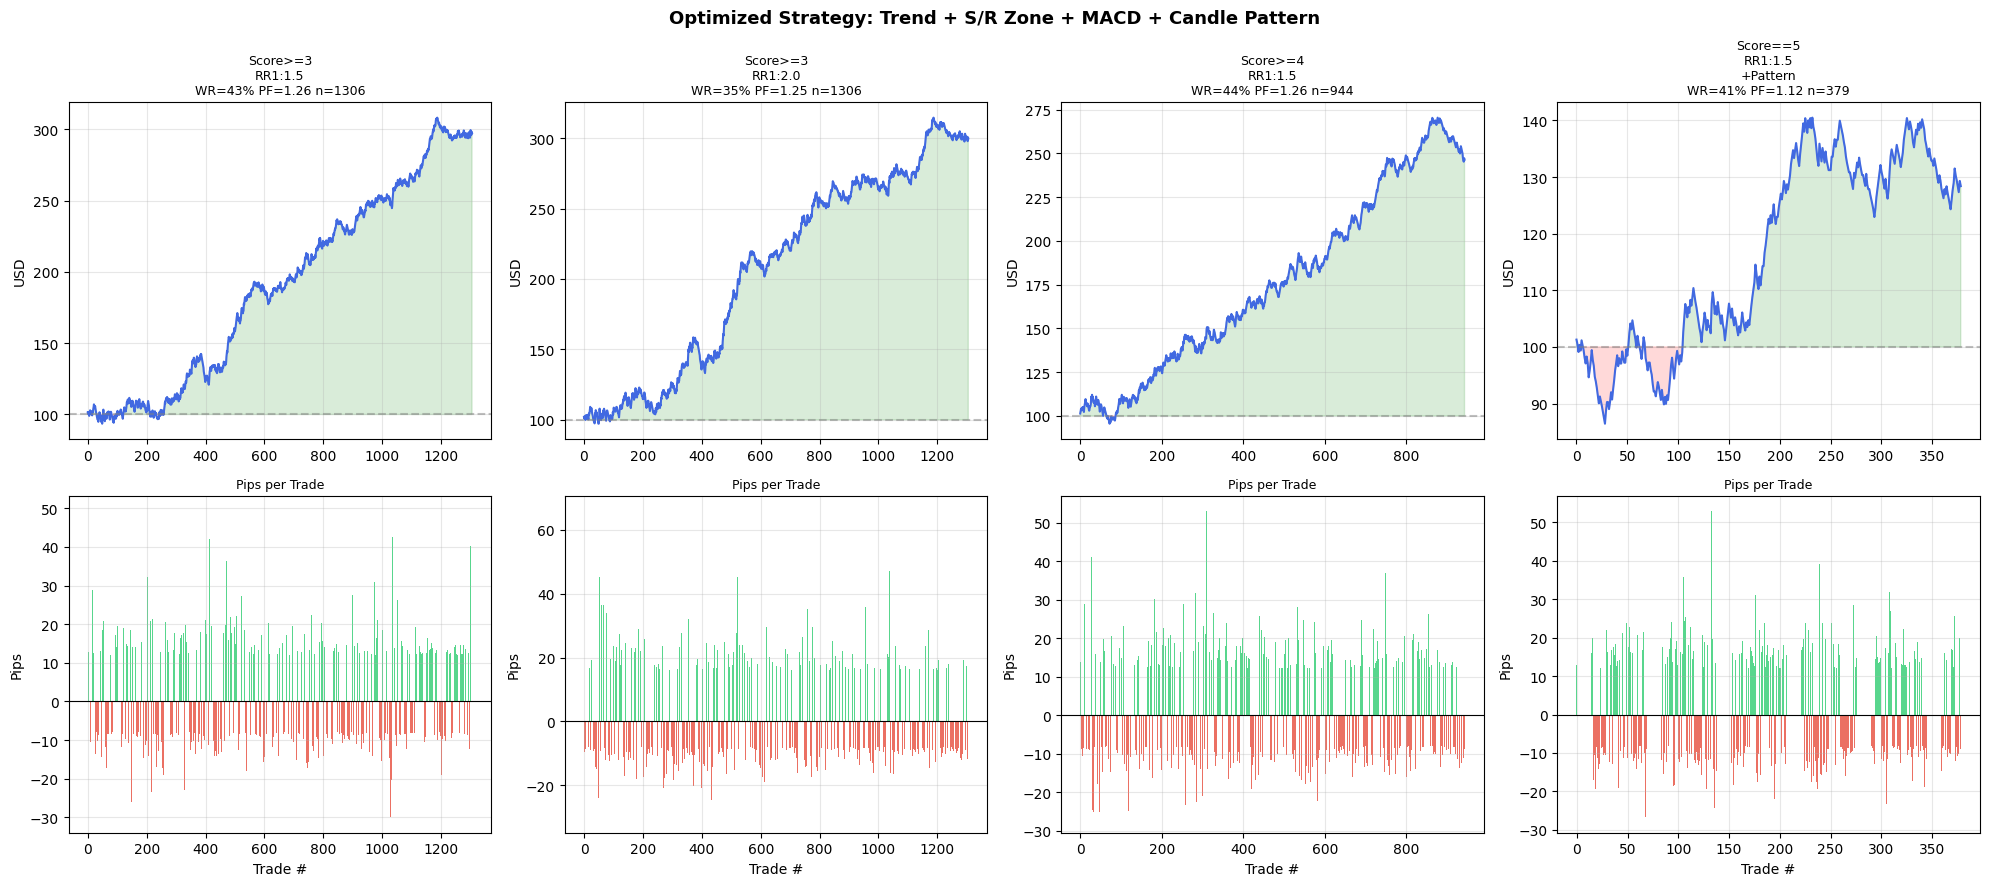

Chart: 09_optimized_result.png


In [8]:
# ── Visualisasi ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Optimized Strategy: Trend + S/R Zone + MACD + Candle Pattern', fontsize=13, fontweight='bold')

scenarios = [
    (t_s3_r15, 'Score>=3\nRR1:1.5'),
    (t_s3_r20, 'Score>=3\nRR1:2.0'),
    (t_s4_r15, 'Score>=4\nRR1:1.5'),
    (t_s5_r15, 'Score==5\nRR1:1.5\n+Pattern'),
]

for col, (trades, label) in enumerate(scenarios):
    if trades is None or len(trades) == 0: continue
    wr  = (trades['outcome']=='win').mean()*100
    gp  = trades.loc[trades['pips']>0,'pips'].sum()
    gl  = abs(trades.loc[trades['pips']<0,'pips'].sum() or 1)
    pf  = gp/gl

    ax = axes[0, col]
    ax.plot(range(len(trades)), trades['equity'], color='royalblue', lw=1.5)
    ax.axhline(100, color='gray', ls='--', alpha=0.5)
    ax.fill_between(range(len(trades)), trades['equity'], 100,
                    where=trades['equity']>=100, alpha=0.15, color='green')
    ax.fill_between(range(len(trades)), trades['equity'], 100,
                    where=trades['equity']<100,  alpha=0.15, color='red')
    ax.set_title(f'{label}\nWR={wr:.0f}% PF={pf:.2f} n={len(trades)}', fontsize=9)
    ax.set_ylabel('USD'); ax.grid(True, alpha=0.3)

    ax = axes[1, col]
    colors = ['#2ecc71' if p>0 else ('#e74c3c' if p<0 else '#f39c12') for p in trades['pips']]
    ax.bar(range(len(trades)), trades['pips'], color=colors, alpha=0.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'Pips per Trade', fontsize=9)
    ax.set_xlabel('Trade #'); ax.set_ylabel('Pips'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('09_optimized_result.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart: 09_optimized_result.png')

In [9]:
# ── Detail: Win Rate per Jam & per Arah ───────────────────────────────────
best = t_s4_r15 if len(t_s4_r15) > 0 else t_s3_r15
lbl  = 'Score>=4 RR1:1.5' if len(t_s4_r15) > 0 else 'Score>=3 RR1:1.5'

if best is not None and len(best) > 0:
    print(f'=== {lbl} — Win Rate per Arah ===')
    for d in ['buy','sell']:
        t = best[best['direction']==d]
        if len(t)==0: continue
        wr = (t['outcome']=='win').mean()*100
        print(f'  {d.upper():4s}: {len(t):3d} trades | WR: {wr:.1f}% | Pips: {t["pips"].sum():+.1f}')

    print(f'\n=== {lbl} — Win Rate per Jam UTC (min 3 trades) ===')
    best2 = best.copy()
    best2['hour'] = pd.to_datetime(best2['datetime']).dt.hour
    hr = best2.groupby('hour').apply(lambda x: pd.Series({
        'trades': len(x),
        'wins':   (x['outcome']=='win').sum(),
        'wr':     (x['outcome']=='win').mean()*100,
        'pips':   round(x['pips'].sum(),1)
    }), include_groups=False).reset_index()
    hr = hr[hr['trades']>=3].sort_values('wr', ascending=False)
    print(hr[['hour','trades','wins','wr','pips']].to_string(index=False))

=== Score>=4 RR1:1.5 — Win Rate per Arah ===
  BUY : 493 trades | WR: 41.4% | Pips: +576.2
  SELL: 451 trades | WR: 46.1% | Pips: +887.6

=== Score>=4 RR1:1.5 — Win Rate per Jam UTC (min 3 trades) ===
 hour  trades  wins        wr   pips
    2    10.0   7.0 70.000000   72.7
    8    10.0   7.0 70.000000   67.9
    3    16.0   9.0 56.250000   57.8
   16    97.0  52.0 53.608247  437.9
   12    41.0  21.0 51.219512  116.5
   15    82.0  41.0 50.000000  247.7
    1    24.0  12.0 50.000000  169.5
    5    14.0   7.0 50.000000   30.5
   10    84.0  40.0 47.619048  147.4
   17   102.0  47.0 46.078431  196.2
    6    11.0   5.0 45.454545    6.1
    9    38.0  17.0 44.736842   48.7
   11    57.0  25.0 43.859649   56.7
   13    31.0  13.0 41.935484   41.9
   20    24.0  10.0 41.666667   38.1
   22    29.0  12.0 41.379310   27.6
   19    49.0  20.0 40.816327    5.1
   18    69.0  28.0 40.579710   26.8
    7     8.0   3.0 37.500000   -1.6
   14    24.0   8.0 33.333333  -27.3
   21    35.0  11.0 31

In [10]:
# ── Simpan & Kesimpulan ────────────────────────────────────────────────────
if t_s4_r15 is not None and len(t_s4_r15)>0:
    t_s4_r15.to_csv('09_best_trades.csv', index=False)
    print('Disimpan: 09_best_trades.csv')

print()
print('='*52)
print('  KESIMPULAN STRATEGI')
print('='*52)
print('  Komponen signal kuat:')
print('  [1] H1 uptrend/downtrend (EMA50+EMA200)')
print('  [2] Harga di S/R Zone H1 (500 candle)')
print('  [3] MACD histogram arah searah signal')
print('  [4] EMA9 vs EMA21 M15 searah signal')
print('  [5] Candle pattern (pin bar/engulfing)')
print()
print('  Score >= 3 = signal valid')
print('  Score >= 4 = signal kuat')
print('  Score == 5 = signal terkuat (pattern hadir)')
print('='*52)

Disimpan: 09_best_trades.csv

  KESIMPULAN STRATEGI
  Komponen signal kuat:
  [1] H1 uptrend/downtrend (EMA50+EMA200)
  [2] Harga di S/R Zone H1 (500 candle)
  [3] MACD histogram arah searah signal
  [4] EMA9 vs EMA21 M15 searah signal
  [5] Candle pattern (pin bar/engulfing)

  Score >= 3 = signal valid
  Score >= 4 = signal kuat
  Score == 5 = signal terkuat (pattern hadir)
